# Анализ рыночной стоимости недвижимости

На основании данных сервиса [Яндекс.Недвижимость](https://realty.yandex.ru/) необходимо провести исследовательский анализ данных и установить параметры, которые влияют на цену объектов. В дальнейшем это позволит построить автоматизированную систему для отслеживания аномалий и мошеннической деятельности.

**Данные:**
Архив объявлений о продаже квартир в Санкт-Петербурге и Ленинградской области за несколько лет. По каждому объекту доступно два вида данных:
- пользовательские (площадь, высота потолков и т.п.)
- автоматические на основе картографических данных (расстояние до центра и других объектов, кол-во парков и водоемов)

### Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.data_prepare import data_info
from src.visualization import hist_with_median


In [2]:
data = pd.read_csv('data/real_estate_data.csv', sep='\t', parse_dates=['first_day_exposition'])
data.head(2)
data_info(data)


Размер таблицы (23699, 22)


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.7,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          2775 non-null   object        
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

,count,mean,min,25%,50%,75%,max,std
total_images,23699.0,9.858475,0.0,6.0,9.0,14.0,50.0,5.682529
last_price,23699.0,6541548.771552,12190.0,3400000.0,4650000.0,6800000.0,763000000.0,10887013.267545
total_area,23699.0,60.348651,12.0,40.0,52.0,69.9,900.0,35.654083
first_day_exposition,23699,2017-11-08 21:55:18.975484160,2014-11-27 00:00:00,2017-05-12 12:00:00,2017-12-12 00:00:00,2018-08-26 00:00:00,2019-05-03 00:00:00,NaN
rooms,23699.0,2.070636,0.0,1.0,2.0,3.0,19.0,1.078405
ceiling_height,14504.0,2.771499,1.0,2.52,2.65,2.8,100.0,1.261056
floors_total,23613.0,10.673824,1.0,5.0,9.0,16.0,60.0,6.597173
living_area,21796.0,34.457852,2.0,18.6,30.0,42.3,409.7,22.030445
floor,23699.0,5.892358,1.0,2.0,4.0,8.0,33.0,4.885249
kitchen_area,21421.0,10.569807,1.3,7.0,9.1,12.0,112.0,5.905438


is_apartment            20924
parks_nearest           15620
ponds_nearest           14589
balcony                 11519
ceiling_height           9195
airports_nearest         5542
cityCenters_nearest      5519
ponds_around3000         5518
parks_around3000         5518
days_exposition          3181
kitchen_area             2278
living_area              1903
floors_total               86
locality_name              49
total_images                0
last_price                  0
studio                      0
floor                       0
rooms                       0
first_day_exposition        0
total_area                  0
open_plan                   0
dtype: int64

Количество явных дубликатов: 0


In [3]:
data['is_apartment'].unique()


array([nan, False, True], dtype=object)

По первичному анализу данных видно, что типы данных для некоторых полей не соответствуют информации. Скорректируем:
- `floors_total`, `balcony` - кол-во балконов и этажей могут принимать только целые значения, поменяем тип на int.
- `days_exposition` - у нас нет данных о времени размещения, следовательно кол-во дней тоже может быть только целым числом.
- `is_apartment` - поле содержит логические значения <span style="color:green">False</span> и <span style="color:green">True</span>. Заменим тип данных на соответствующий им булев.

In [4]:
for col in ['floors_total', 'balcony', 'days_exposition']:
        data[col] = pd.to_numeric(data[col], errors='coerce').astype('Int64', errors='ignore')

data['is_apartment'] = data['is_apartment'].astype('boolean')


Приведем название колонок к общему виду, поле c идентификацией апартаментов приведем в соответствие с другими булевыми признаками.

In [5]:
data = data.rename(columns={'is_apartment': 'apartment',
                            'parks_around3000': 'parks_around_3000m',
                            'ponds_around3000': 'ponds_around_3000m',
                            'cityCenters_nearest': 'city_center_nearest'})


Пропуски в данных неравномерны: кол-во пропусков для разных полей значительно различается. Необходим дополнительный анализ по каждому полю, чтобы определить лучшую стратегию по их обработке.

Также в даннхы есть явные аномалии. Напрмиер, максимальная высота потолка - 100м и слишком большие значения по площади (жилой/кухни). Возможно, есть проблема с единицей измерений или это просто некорректный ввод данных. Посмотрим дополнительно на гистограммы по количественным переменным.

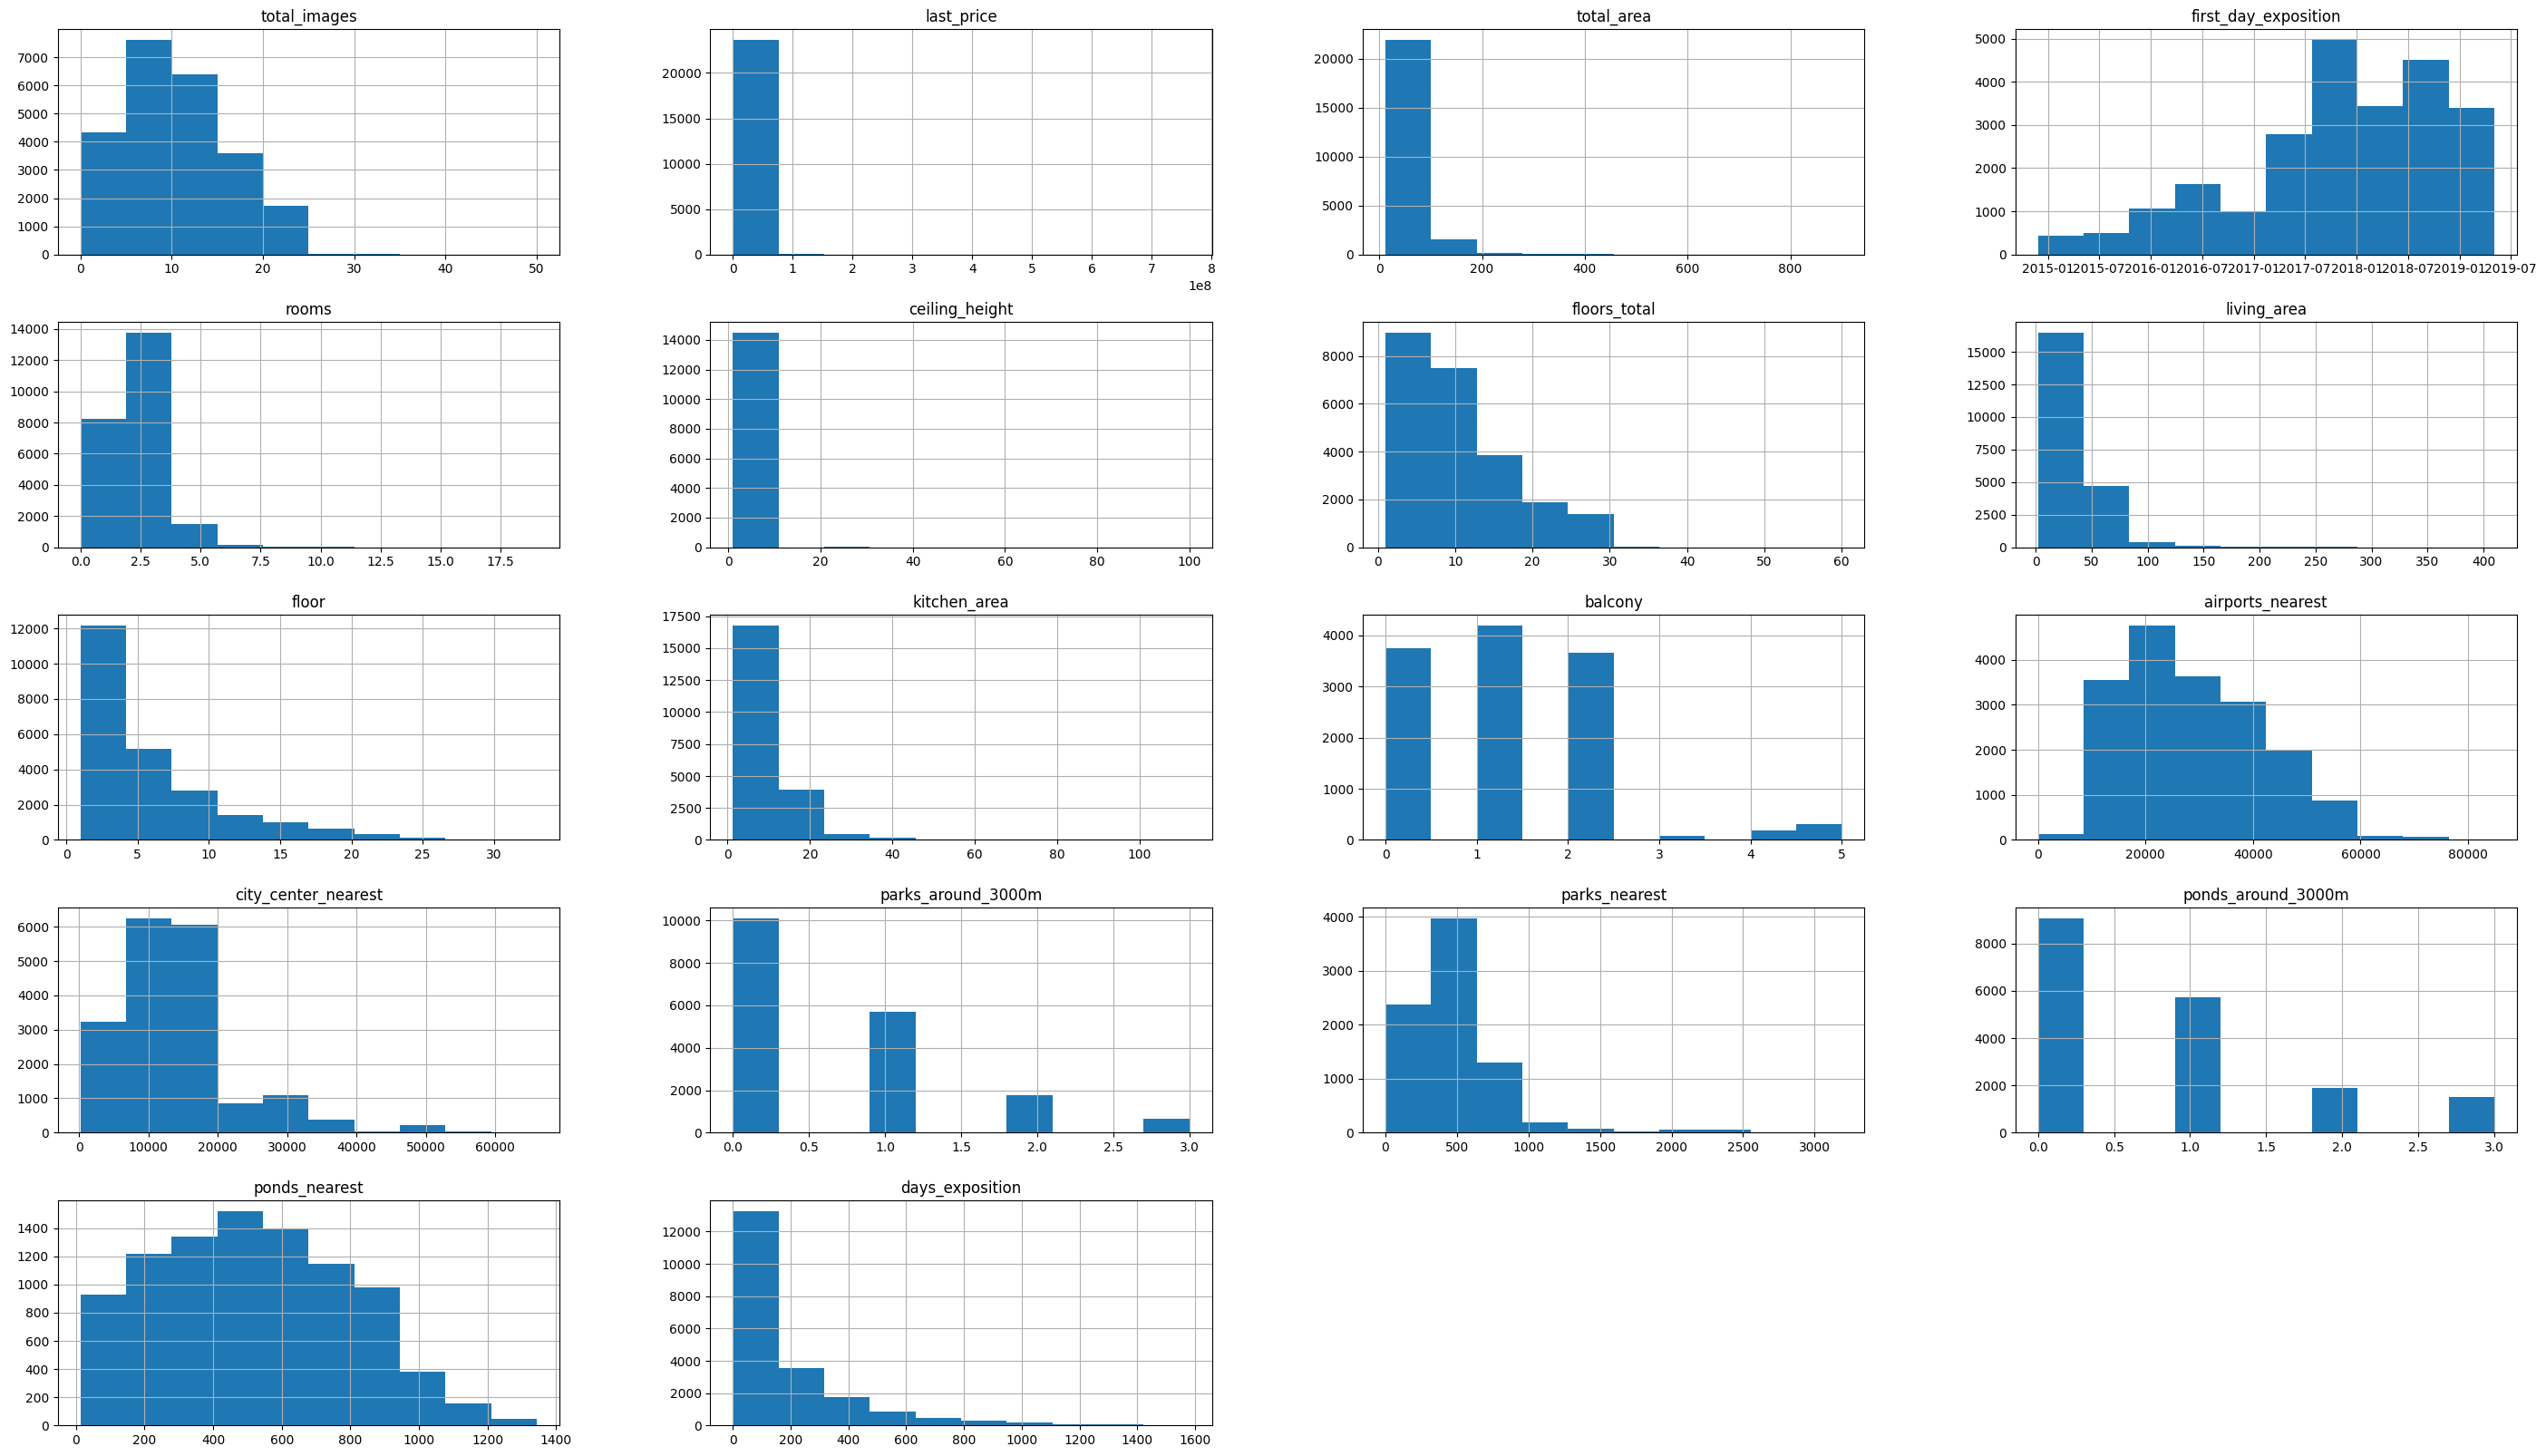

In [6]:
data.hist(figsize=(35, 20));


Из построенных графиков видно, что:
- Распределения большинства количественных признаков имеют выраженную правостороннюю асимметрию и длинные хвосты (цена, площади, срок экспозиции, расстояния до объектов инфраструктуры), что указывает на наличие редких крупных значений и потенциальных выбросов.
- Основная масса объявлений относится к типовым квартирам: 1–3 комнаты, умеренные площади, стандартная этажность; при этом встречаются единичные экстремальные значения (например, по `ceiling_height`, площадям и `last_price`), требующие дополнительной проверки и очистки данных.


<b>Вывод по разделу "Загрузка данных"</b>

В данных содержится 23 699 объявлений и 22 признака.
- Для полей `floors_total`, `balcony`, `days_exposition` и `is_apartment` был скорректирован тип данных, в соответствии с содержащейся в поле информацией
- Имена полей приведены к единому формату

Первичный анализ показал, что в данных присутствует значительное количество пропусков и возможны аномалии, которые будут обработаны в ходе последующей предобработки данных.

### Предобработка данных

Рассмотрим каждое поле по-отдельности внимательнее.

#### `balcony` - число балконов,  `is_apartment` - апартаменты (булев тип)

In [7]:
print(data['balcony'].unique())
print('Доля апартаментов:', (data.query('apartment == True')['apartment'].count() \
                             /data.shape[0]*100).round(2), '%')


<IntegerArray>
[<NA>, 2, 0, 1, 5, 4, 3]
Length: 7, dtype: Int64
Доля апартаментов: 0.21 %


Столбцы `apartment` и `balcony` заполняются продавцом. Если продавец оставил эти поля пустыми, скорее всего в квартире нет балкона и квартира не является апартаментами. Для поля `balcony` заменим пустые значения на 0, а для `apartment` - на <span style="color:green">False</span>. Небольшая доля апартаментов в датасете не противоречит действительности, поэтому считаем такую замену оправданной.

In [8]:
data['balcony'] = data['balcony'].fillna(0)
data['apartment'] = data['apartment'].fillna(False)


#### `ceiling_height` - высота потолков

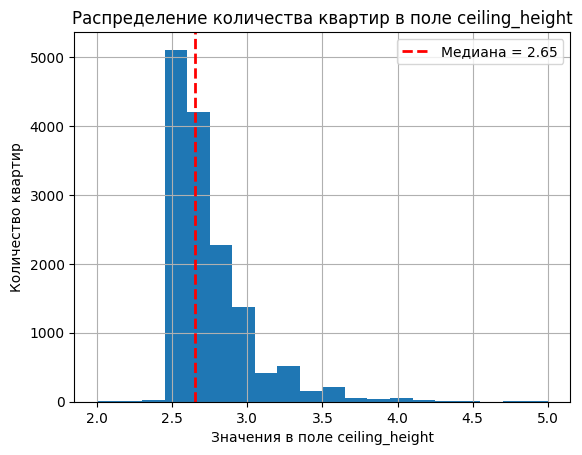

In [9]:
hist_params = {'bins': 20,
               'range': (2, 5)}

hist_with_median(data, 'ceiling_height', **hist_params)


На гистограмме, построенной при просмотре общей информации, видно, что абсолютное большинство значений в поле `ceiling_height` лежит в пределах от 0 до 10 м. Изменив масштаб, видим, что диапазон основных значений 2.5 - 3м.  Эти значения соответствуют среднестатической высоте потолка жилых помещений в РФ на текущий момент. Можно предположить, что продавец не заполнил поле, подразумевая стандартное значение. Заменим пропущенные значения в данном поле медианой (2,65 м), чтобы исключить влияние выбросов, которые есть в данных.

In [10]:
data["ceiling_height"] = data["ceiling_height"].fillna(data["ceiling_height"].median())


#### `kitchen_area` - площадь кухни

In [11]:
print('Количество студий:', data.query('studio == True')['studio'].count())
print('Количество квартир с открытой планировкой:', data.query('open_plan == True')['open_plan'].count())
print('Количество студий с пропущенным значением площади кухни:' \
      ,data.query('kitchen_area.isna() and studio == True')['studio'].count())
print('Количество квартир с открытой планировкой с пропущенным значением площади кухни:' \
      ,data.query('kitchen_area.isna() and open_plan == True')['open_plan'].count())


Количество студий: 149
Количество квартир с открытой планировкой: 67
Количество студий с пропущенным значением площади кухни: 149
Количество квартир с открытой планировкой с пропущенным значением площади кухни: 67


В случае если квартира является студией или имеет открытую планировку, кухня не выделена в отдельное помещение. Следовательно, продавец мог не указать площадь кухни, включив ее в общую. Для всех объявлений отмеченных как студия или открытая планировка(поля `studio`, `open_plan`), площадь кухни не указана. В этом случае можно заменить пропуски на 0. Возможно, в случае остальных пропусков также подразумевалось, что кухни нет. Однако, мы не можем этого гаранировать. Предположить логичную замену в данном случае затруднительно. Оставим значения пустыми.

In [12]:
mask = data["studio"].fillna(False) | data["open_plan"].fillna(False)
data.loc[mask, "kitchen_area"] = data.loc[mask, "kitchen_area"].fillna(0)


#### `living_area` - жилая площадь 

Жилая площадь должна коррелировать с количеством комнат. Попробуем заполнить пропуски медианным значением по количеству комнат.

Количество пропусков по количеству комнат.

In [13]:
data.query('living_area.isna()')['rooms'].value_counts()


rooms
1    659
2    644
3    448
4     91
5     34
0     14
7      6
6      6
9      1
Name: count, dtype: int64

In [14]:
data.loc[data['rooms'] == 1]['living_area'].describe()


count    7388.000000
mean       17.893552
std         3.448422
min         3.000000
25%        16.000000
50%        17.600000
75%        19.000000
max        60.000000
Name: living_area, dtype: float64

Посмотрим на описание данных на примере категории с наибольшим количеством пропусков (1к квартиры). Среднее значение несильно отличается от медианного. Однако, воспользуемся медианой, она будет немного точнее с учетом наличия выбросов. Разброс между максимальной и минимальной площадью достаточно большой.

In [15]:
data['living_area'] = data['living_area'].fillna(
            data.groupby('rooms')['living_area'].transform('median')
        )


Суммарная площадь кухни и жилая не должны превышать общей площади, указанной в объявлении. Проверим наличие таких несоответствий. В случае необходимости скорректируем значения общей площади для таких квартир на фактическую сумму жилой и площади кухни или только жилой. Такой вариант хоть и не учитывает площади других служебных помещений, но будет более корректным. 

In [16]:
data.query('(kitchen_area + living_area) > total_area')[['total_area', 'living_area', 'kitchen_area']].head()


,total_area,living_area,kitchen_area
184,30.20,26.10,6.20
545,23.80,20.00,5.00
551,31.59,30.55,9.28
601,53.70,48.30,7.00
696,34.69,23.43,23.43


In [17]:
data.loc[(data['kitchen_area'] + data['living_area']) > data['total_area'], 'total_area'] = \
     data['kitchen_area'] + data['living_area']


Проверим также несоответствие значений в случаях когда площадь кухни не проставлена.

In [18]:
data.query('living_area > total_area')[['living_area', 'total_area', 'kitchen_area']].head()


,living_area,total_area,kitchen_area
1595,63.6,62.4,NaN
3374,45.0,41.5,NaN
8976,45.0,41.2,NaN
9795,45.0,42.0,NaN
9964,63.6,49.5,NaN


In [19]:
data.loc[data['living_area'] > data['total_area'], 'total_area'] = data['living_area']


Проверим внесенные изменения.

In [21]:
display(data.loc[184:184, ['total_area', 'living_area', 'kitchen_area']])
data.loc[1595:1595, ['total_area', 'living_area', 'kitchen_area']]


,total_area,living_area,kitchen_area
184,32.3,26.1,6.2


,total_area,living_area,kitchen_area
1595,63.6,63.6,NaN


#### `floors_total` - количество этажей в доме

In [22]:
total_floors_median = data['floors_total'].median()
print(total_floors_median)

print('Количество объявлений, где этаж выше медианного значения:', \
      data.query('floors_total.isna() and floor > @total_floors_median')['floor'].count())


9.0
Количество объявлений, где этаж выше медианного значения: 37


In [23]:
data.query('floors_total.isna()')['floor'].unique()


array([ 4,  1, 12,  8,  9, 22, 15,  6,  7,  3, 18, 13, 24, 21, 11,  2,  5,
       19, 20, 14, 17, 23, 10])

Пропуски в поле `floors_total` можно заполнить медианным значением, которое лучше характеризует данные с учетом наличия выбросов. Однако, почти в половине случаев этаж, указанный в объявлении выше, чем медиана. В качестве гипотезы можно предположить, что продавец не указывал этажность дома когда объект продажи находился на последнем этаже. Но среди значений с пропусками этажности в поле `floor` есть несоответствующие стандартной застройке в РФ, поэтому гарантировать, что гипотеза верна для всех случаев нельзя. В тех случаях когда указанный этаж выше медианы заменим пропуск на значение указанного этажа, в остальных случаях - на медиану. 

Чтобы избежать случаев когда указанный в объявлении этаж выше, чем всего этажей в доме при замене добавляем условие проверки. Если указанный этаж выше, чем медианное значение, то заменяем пропуск на значение указанного этажа. Т.е. если этаж = 10, а медиана 9, то пропуск заполняем значением 10. Дополнительно проверим, что в датасете нет записей где этаж выше этажности дома.

In [24]:
conditions = [(data['floor'] < total_floors_median, total_floors_median),
              (data['floor'] >= total_floors_median, data['floor'])]
for condition, fill_value in conditions:
    data.loc[condition, 'floors_total'] = data.loc[condition, 'floors_total'].fillna(fill_value)


Проверим дополнительно, чтобы значение этажа не превышало высотность здания.

In [26]:
data[data['floor'] > data['floors_total']]['floor'].count()


np.int64(0)

#### `locality_name` - название населенного пункта

Избавимся от неявных дубликатов в названии населенного пункта, чтобы упростить себе анализ на последующих этапах.

In [27]:
data['locality_name'].unique()


array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [28]:
data['locality_name'] = (
    data['locality_name']
    .str.lower()
    .str.replace('ё', 'е')
    .replace(['садоводческое некоммерческое товарищество ', 'поселок при железнодорожной станции ', \
              'коттеджный поселок ', 'поселок городского типа ', 'садовое товарищество ', 'городской поселок ', \
              'поселок станции ', 'поселок ', 'деревня ', 'село '], '', regex=True)
)


In [29]:
data['locality_name'].unique()


array(['санкт-петербург', 'шушары', 'янино-1', 'парголово', 'мурино',
       'ломоносов', 'сертолово', 'петергоф', 'пушкин', 'кудрово',
       'коммунар', 'колпино', 'красный бор', 'гатчина', 'федоровское',
       'выборг', 'кронштадт', 'кировск', 'новое девяткино',
       'металлострой', 'лебяжье', 'сиверский', 'молодцово',
       'кузьмоловский', 'новая ропша', 'павловск', 'пикколово',
       'всеволожск', 'волхов', 'кингисепп', 'приозерск', 'сестрорецк',
       'куттузи', 'аннино', 'ефимовский', 'плодовое', 'заклинье',
       'торковичи', 'первомайское', 'красное село', 'понтонный',
       'сясьстрой', 'старая', 'лесколово', 'новый свет', 'сланцы',
       'путилово', 'ивангород', 'шлиссельбург', 'никольское',
       'зеленогорск', 'сосновый бор', 'оржицы', 'кальтино', 'романовка',
       'бугры', 'рощино', 'кириши', 'луга', 'волосово', 'отрадное',
       'павлово', 'оредеж', 'копорье', 'молодежное', 'тихвин', 'победа',
       'нурма', 'синявино', 'тосно', 'стрельна', 'бокситогорск',

In [30]:
data.duplicated().sum()


np.int64(0)

Т.к. пропущенных значений в таблице немного, заменим эти значения на "unknown".

In [31]:
data['locality_name'] = data['locality_name'].fillna('unknown')


#### `cityCenters_nearest` - расстояние до центра, `airports_nearest` - расстояние до ближайшего аэропорта

In [32]:
data_distances = (data
                     .groupby('locality_name').agg({'city_center_nearest':['count'], 'airports_nearest':['count'], 'total_images':['count']})
                     .droplevel(1,axis=1)
                     .query('city_center_nearest != 0 and city_center_nearest != total_images and locality_name not in ["санкт-петербург", "unknown"]')
                     .reset_index()
                )
data_distances


,locality_name,city_center_nearest,airports_nearest,total_images
0,колпино,337,337,338
1,красное село,176,176,178
2,кронштадт,95,95,96
3,ломоносов,132,132,133
4,мурино,2,2,590
5,пушкин,368,369,369
6,шушары,436,436,440
7,щеглово,1,1,24


In [33]:
data.query('locality_name == "кронштадт"')[['city_center_nearest', 'airports_nearest']].describe()


,city_center_nearest,airports_nearest
count,95.000000,95.000000
mean,49195.726316,67469.263158
std,1647.487232,1648.522480
min,46657.000000,64931.000000
25%,47163.000000,65418.000000
50%,49575.000000,67850.000000
75%,50598.500000,68873.000000
max,51511.000000,69785.000000


После удаления неявных дубликатов в названиях можно выделить ряд населенных пунктов, в которых расстояние до центра (Санкт-Петербурга) и ближайшего аэропорта указано только для части объявлений. Для таких объявлений можно заменить отстутвующие значения на средние по населенному пункту. Для небольших поселений разброс не должен быть очень большим. На примере Кронштадта видим, что медиана близка к среднему, что говорит об отстутсвии выбросов. Стандартное отклонение около 1,5км, что незначительно с учетом величины значений. Для Санкт-Петербурга, а также других населенных пунктов без информации о расстоянии оставим пропуски незаполненными.

In [34]:
for col in ['city_center_nearest', 'airports_nearest']:
    data[col] = data[col].fillna(
            data.groupby('locality_name')[col].transform('mean')
        )


Вероятно, при сборе данных о расстоянии, картографический сервис не мог корректно определить название населенного пункта, если его написание отличалось от стандартного. Можно попробовать доработать этот момент в дальнейшем и сократить количество пропусков. 

Дополнительно переведем расстояние до центра в км и округлим до ближайшего целого.

In [ ]:
data['city_center_nearest'] = (data['city_center_nearest']/1000).round()
data['city_center_nearest'].head(2)


0    16.0
1    19.0
Name: city_center_nearest, dtype: float64

#### `parks_around3000` - число парков в радиусе 3 км, `ponds_around3000` - число водоёмов в радиусе 3 км

Скорее всего пропущенные значения говорят о том, что парком и водоёмов нет в радиусе 3 км. Заменим пропуски на 0. Количество парков и водоемов может принимать только целые значения, поменяем тип на int.

In [35]:
data['parks_around_3000m'] = data['parks_around_3000m'].fillna(0).astype(int)
data['ponds_around_3000m'] = data['ponds_around_3000m'].fillna(0).astype(int)


#### `parks_nearest` - расстояние до ближайшего парка, `ponds_nearest` - расстояние до ближайшего водоема

По гистограмме из п.1 исследования мы увидели, что значения полей `parks_nearest` и `ponds_nearest` лежат в диапазоне до 3 и 1,5 км соответственно. Значения слишком малы, чтобы заполнить их по аналогии с расстоянием до центра или аэропорта. Вероятно, пропуски означают, что поблизости нет парка или водоема. Оставим значения пустыми.

In [36]:
# Есть ли поблизости парки с неуказанным расстоянием
data.query('parks_around_3000m !=0 and parks_nearest.isna()')['parks_around_3000m'].count()


np.int64(0)

In [37]:
# Есть ли поблизости водоемы с неуказанным расстоянием
data.query('ponds_around_3000m !=0 and ponds_nearest.isna()')['ponds_around_3000m'].count()


np.int64(0)

#### `days_exposition` - количество дней до закрытия объявления

Скорее всего пропуски связаны с тем, что квартира еще не продана и объявление не закрыто. Оставим значения пустыми, т.к. предугадать сроки продажи затруднительно. Несмотря на то, что количество дней должно быть целочисленным, в связи с наличием пропусков оставим пока тип данных неизменным.

<b>Вывод по разделу "Предобработка данных"</b>

В ходе предобработки данных было выполнено следующее:
    
- заполнены пропуски в колонках с числом парков и водоемов на расстоянии до 3км, наличием балкона, является ли объект недвижимости апартаментами, высота потолков и общее количество этажей в здании
- частично, там где это было возможно, заполнены пропуски в колонках с площадью кухни и расстоянием до центра города и аэропорта
- тип данных для целочисленных значений изменен на int (кол-во парков и водоемов)
- расстояние до центра переведно в км и округлено до ближайшего целого.

Среди возможных причин возникновения пропусков в данных можно выделить:
- данные не предоставлены продавцом при размещении объявления. Чтобы избежать этого в дальнейшем можно сделать заполнение этих пунктов на сайте обязательным
- проблемы со сбором информации из картографического сервиса при идентификации части населенных пунктов (например Мурино)
- ошибки в сборе данных, на этапе загрузки или выгрузки
- сбои в системе сбора информации

### Генерация признаков

На основании имеющихся данных выведем цену за квадратный метр.

In [38]:
data['price_square_meter'] = (data['last_price']/data['total_area']).round(2)


Для удобства дальнейшего анализа выделим день, месяц и год размещения объявления в отдельные поля.

In [39]:
def add_date_parts(df: pd.DataFrame,
                   col: str = 'first_day_exposition') -> pd.DataFrame:
    '''Добавление в отдельные колонки: день недели, месяц и год размещения объявления.'''
    df = df.copy()

    df['weekday_exposition'] = df[col].dt.weekday
    df['month_exposition'] = df[col].dt.month
    df['year_exposition'] = df[col].dt.year
    return df


In [40]:
data = add_date_parts(data)
data.head(2)


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,apartment,...,city_center_nearest,parks_around_3000m,parks_nearest,ponds_around_3000m,ponds_nearest,days_exposition,price_square_meter,weekday_exposition,month_exposition,year_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,16028.0,1,482.0,2,755.0,NaN,120370.37,3,3,2019
1,7,3350000.0,40.4,2018-12-04,1,2.65,11,18.6,1,False,...,18603.0,0,NaN,0,NaN,81.0,82920.79,1,12,2018


Как правило, стоимость недвижимости, расположенной на первом и последнем этажах отличается от других вариантов. Проверим наблюдаетяс ли эта закономерность в наших данных. Для этого введем дополнительный категориальный признак на основе этажа со значениями: первый/послений/другой.

In [41]:
def floor_category(df: pd.DataFrame, 
                   floor_col: str = 'floor',
                   total_col: str = 'floors_total') -> pd.Series:
    
    '''Функция для создания категориальной переменной на основе этажа, где 
     этаж кодируется в зависимости от своего значения как первый / последний / другой.'''
    
    floor = df[floor_col]
    total = df[total_col]

    return pd.Series(
        np.select(
            [floor.eq(1), floor.eq(total)],
            ['первый', 'последний'],
            default='другой',
        ),
        index=df.index
    )


In [42]:
data['floor_category'] = floor_category(data)
data['floor_category'].unique()


array(['другой', 'первый', 'последний'], dtype=object)

<b>Вывод по разделу "Генерация признаков"</b>

В ходе подготовки данных к анализу:
- добавлены столбцы с информацией о цене квадратного метра, годе, месяце и дне недели публикации объявления
- категоризованы данные об этаже

### Исследовательский анализ данных

#### Высота потолков

По гистограмме построенной в начале исследования, а также при анализе пропусков мы определили, что основная часть значений лежит в диапазоне от 2,5 до 3,5 метров, что соответствует принятым в РФ нормам строительства. В отдельных случаях высота потолков может достигать 10м (лофты, элитное жилье, коммерческие помещения). Таким образом, значения выше 10м и ниже 2м скорее всего связаны с ошибкой в данных. Посмотрим на распределение в диапазоне от 10м.

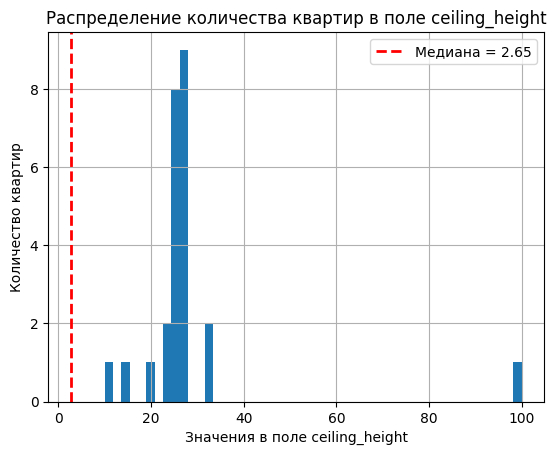

In [44]:
hist_params = {'bins': 50,
               'range': (10, 100)}

hist_with_median(data, 'ceiling_height', **hist_params)


Пик значений приходится на диапазон 20-35м. Скорее всего это соответствует вещественным значениям 2.5 - 3.5м. Разделим высоту потолка превышающую 20 метров на 10.

In [45]:
data['ceiling_height'] = np.where(
    data['ceiling_height'] >= 20,
    data['ceiling_height'] / 10,
    data['ceiling_height']
)


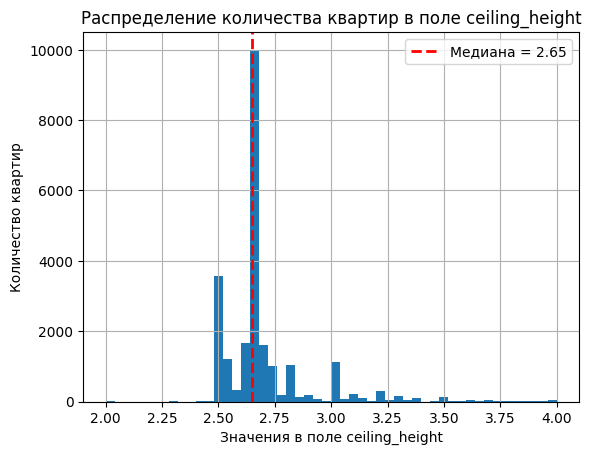

In [46]:
hist_params = {'bins': 50,
               'range': (2, 4)}

hist_with_median(data, 'ceiling_height', **hist_params)


In [47]:
print('Количество обявлений вне диапазона 2 - 10м:', \
      data.query('ceiling_height < 2 or ceiling_height > 10')['ceiling_height'].count())
print('Значения вне диапазона 2 - 10м:', \
      data.query('ceiling_height < 2 or ceiling_height > 10')['ceiling_height'].unique())


Количество обявлений вне диапазона 2 - 10м: 5
Значения вне диапазона 2 - 10м: [ 1.2  14.    1.75 10.3   1.  ]


Количество объявлений вне принятого диапазона небольшое, удалим их из данных.

In [48]:
data = data[(data['ceiling_height'] >= 2) & (data['ceiling_height'] <= 10)]


<b>Вывод</b>

Больше всего предложений с высотой потолка 2.65м. Это стандартная высота для жилого строительства в РФ.

#### Общая площадь

In [49]:
data['total_area'].describe()


count    23694.000000
mean        60.381865
std         35.658110
min         12.000000
25%         40.000000
50%         52.000000
75%         70.000000
max        900.000000
Name: total_area, dtype: float64

По гистограмме построенной в начале исследования видим, что общая площадь для большинства составляет до 100кв.м. По описанию данных видим, что выборка неоднородна, стандартное отклонение в 35 кв.м. значительна для величины среднего значения. Есть единичные объявления с площадью выше 200 кв.м. с максимумом - 900 кв.м. Такие единичные объявления могут встречаться, возможно, это коммерческая недвижимость. Однако, эти выбросы значительно влияют на смещение в данных. На текущем этапе оставим выборку без изменений. Вернемся к этому после анализа влияния переменных. Для общей оценки построим гистограмму для диапазона площади от 0 до 100 кв.м. 

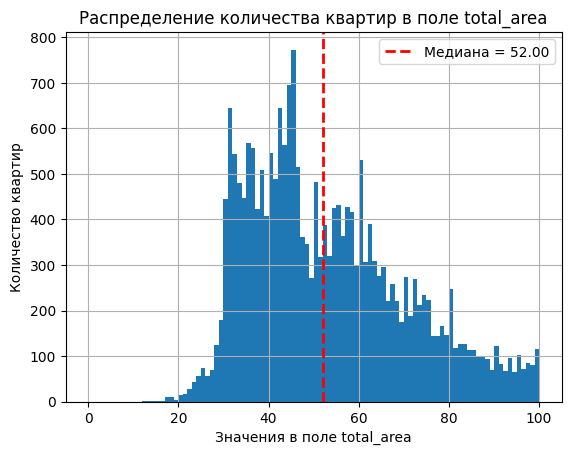

In [50]:
hist_params = {'bins': 100,
               'range': (0, 100)}

hist_with_median(data, 'total_area', **hist_params)


<b>Вывод</b>

Основная масса объявлений предлагает квартиры площадью от 30 до 60 кв.м. с пиком около 45 кв.м. Такое распределение соответствует действительности и наиболее распространенной площади для 1-3 комн.квартир.

#### Жилая площадь

In [51]:
data['living_area'].describe()


count    23694.000000
mean        34.323940
std         21.702241
min          2.000000
25%         18.400000
50%         30.300000
75%         42.700000
max        409.700000
Name: living_area, dtype: float64

Ситуация аналогична общей площади. 

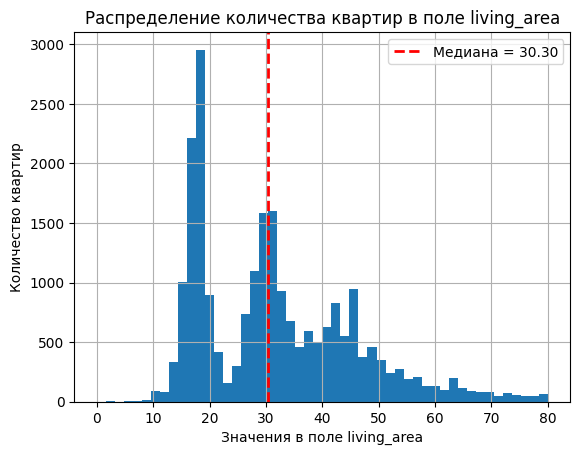

In [52]:
hist_params = {'bins': 50,
               'range': (0, 80)}

hist_with_median(data, 'living_area', **hist_params)


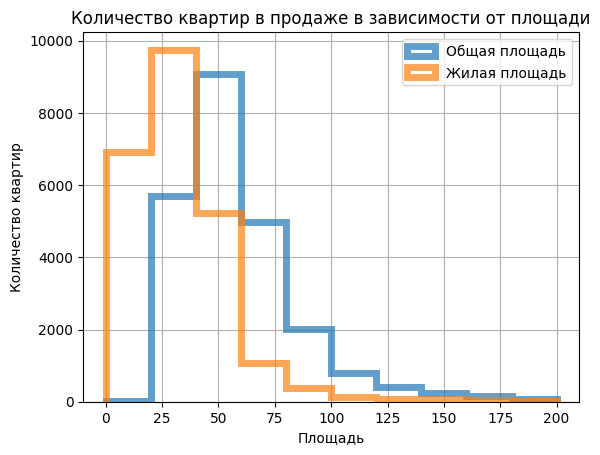

In [53]:
ax = data.plot(kind='hist', 
               y='total_area', 
               histtype='step',
               linewidth=5, 
               range=(0,200),
               alpha=0.7, 
               label='Общая площадь'
              )

data.plot(kind='hist', 
          y='living_area', 
          histtype='step',
          linewidth=5, 
          range=(0,200),
          alpha=0.7, 
          label='Жилая площадь',
          ax=ax, 
          grid=True, 
          legend=True
        )
plt.title('Количество квартир в продаже в зависимости от площади')
plt.xlabel('Площадь')
plt.ylabel('Количество квартир')
plt.show();


Жилая площадь должна быть прямо пропорциональна общей, чем выше общая площадь, тем выше жилая. Посмотрев на распределения на общей гистограмме по этим двум полям видим, что данные соответствуют друг другу.  В диапазоне выше 200 кв.м. также встречаются единичные объявления, которые соответствуют аналогичным с жилой площадью. Объявлений где жилая площадь превышает общую нет. Явных несостыковок нет. Оставим датасет пока без изменений, вернемся позднее.

<b>Вывод</b>

На гистограмме видны 3 пика: 16-18м, 28-30м и около 40м. Такое распределение соответствует действительности и наиболее распространенной площади для 1-3 комн.квартир. Предварительно можно предположить, что в датасете преобладают объявления по продаже 1к кв., с чем связано преобладание жилой площади в 18м.

#### Площадь кухни

In [54]:
data['kitchen_area'].describe()


count    21633.000000
mean        10.464716
std          5.969527
min          0.000000
25%          7.000000
50%          9.000000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

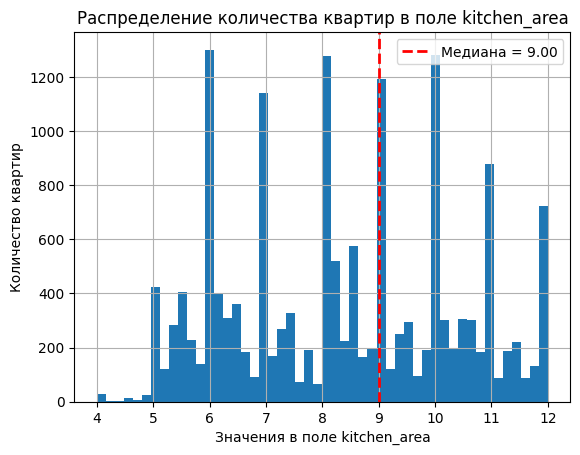

In [55]:
hist_params = {'bins': 50,
               'range': (4, 12)}

hist_with_median(data, 'kitchen_area', **hist_params)


In [56]:
data['kitchen_area'].value_counts().head(5)


kitchen_area
6.0     1300
10.0    1261
8.0     1110
9.0     1101
7.0     1062
Name: count, dtype: int64

<b>Вывод</b>

Количество предложений с площадью кухни в диапазоне от 6 до 10 м для целых значений практически равно. 

#### Цена объекта

In [57]:
data['last_price'].describe()


count    2.369400e+04
mean     6.541980e+06
std      1.088810e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.800000e+06
max      7.630000e+08
Name: last_price, dtype: float64

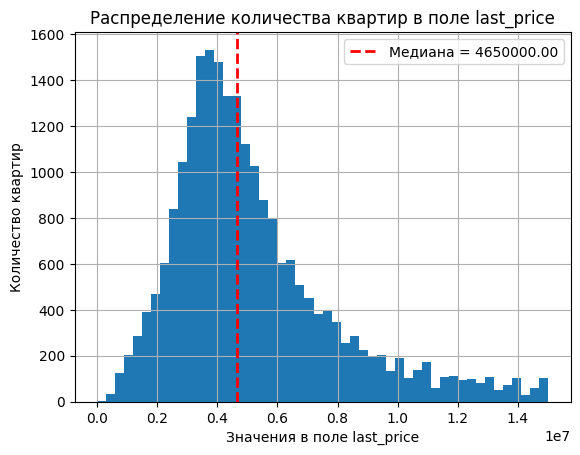

In [58]:
hist_params = {'bins': 50,
               'range': (0, 15000000)}

hist_with_median(data, 'last_price', **hist_params)


<b>Вывод</b>

Большая часть объявлений находится в диапазоне от 3.5 до 4.5 млн. 

#### Количество комнат

In [59]:
data['rooms'].describe()


count    23694.000000
mean         2.070735
std          1.078473
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

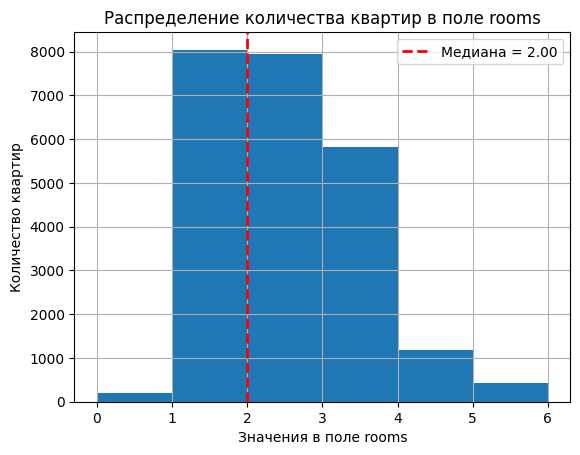

In [60]:
hist_params = {'bins': 6,
               'range': (0, 6)}

hist_with_median(data, 'rooms', **hist_params)


<b>Вывод</b>

Среди предложений преобладают 1 и 2-комнатные квартиры, что ранее можно было заметить и по жилой/общей площади. 

#### Тип этажа квартиры

Для типа этажа построим круговую диаграмму, т.к. на ней будет лучше видна доля объявлений.

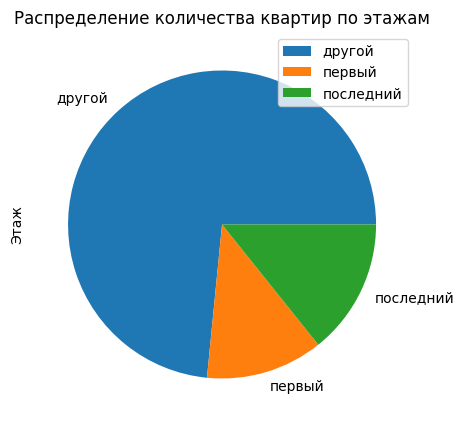

In [61]:
(data
     .pivot_table(index='floor_category', values='floor', aggfunc='count')
     .plot(title='Распределение количества квартир по этажам',
           y='floor', kind='pie', grid=True, figsize=(12, 5))
)
plt.ylabel('Этаж')
plt.show();


<b>Вывод</b>

Доля предложений на первом и последнем этаже составляет почти четверть от общего числа. 

#### Общее количество этажей в доме

In [62]:
data['floors_total'].describe()


count    23694.000000
mean        10.677513
std          6.589343
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

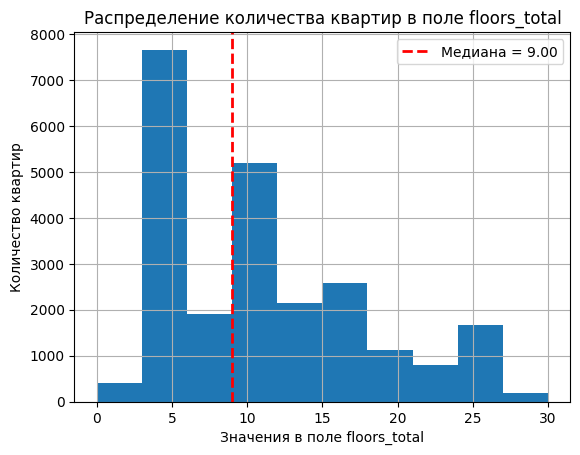

In [63]:
hist_params = {'range': (0, 30)}

hist_with_median(data, 'floors_total', **hist_params)


In [64]:
data.query('floors_total > 40')['floors_total'].unique()


array([60, 52])

Самое высокое здание в Санкт-Петербурге высотой 87 этажей - Лахта-Центр. Остальные здания значительно ниже, а построек в 52 и 60 этажей в городе нет. В Ленинградской области таких объектов также быть не может. Удалим объявления с этажностью выше 40. 

In [65]:
data = data[data['floors_total'] < 40]


<b>Вывод</b>

Наибольшее количество предложений в 5-этажных зданиях, затем - 9.

#### Расстояние до центра города в км

In [66]:
data['city_center_nearest'].describe()


count    18864.000000
mean        14.451495
std          8.603674
min          0.000000
25%          9.000000
50%         13.000000
75%         17.000000
max         66.000000
Name: city_center_nearest, dtype: float64

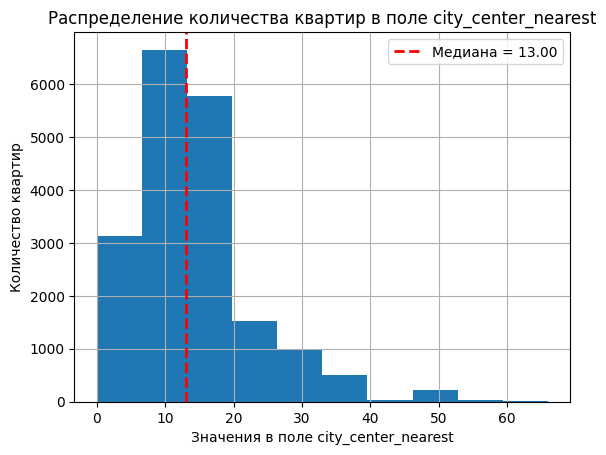

In [67]:
hist_params = {}

hist_with_median(data, 'city_center_nearest', **hist_params)


<b>Вывод</b>

В Санкт-Петербурге объявлений больше всего, как в самом крупном городе из рассмтариваемых в датасете. Больше всего предложений на расстоянии 8-12 км от центра. На расстоянии около 50 км, вероятно, находится небольшой районный центр, т.к. там объявлений чуть больше чем на расстоянии от 40 км. 

#### Расстояние до ближайшего парка

In [68]:
data['parks_nearest'].describe()


count    8075.000000
mean      490.816347
std       342.374714
min         1.000000
25%       288.000000
50%       455.000000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64

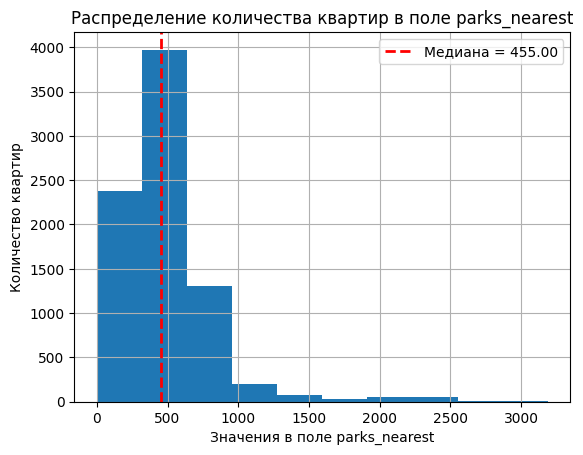

In [69]:
hist_with_median(data, 'parks_nearest', **hist_params)


<b>Вывод</b>

У большинства предложений есть парк в пределах 0,8 - 1,2 км.

#### Скорость продажи в днях

In [70]:
data['days_exposition'].describe()


count    20511.000000
mean       180.901906
std        219.756223
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64

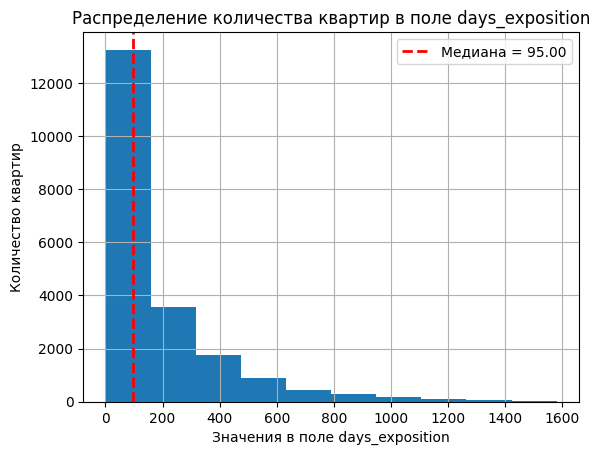

In [71]:
hist_with_median(data, 'days_exposition', **hist_params)


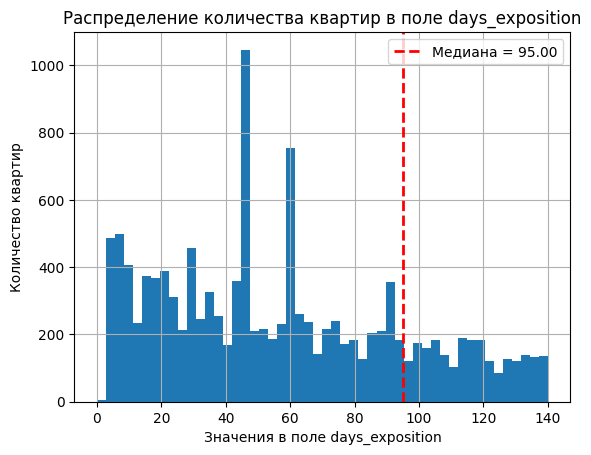

In [72]:
hist_params = {'bins': 50,
               'range': (0, 140)}

hist_with_median(data, 'days_exposition', **hist_params)


<b>Вывод</b>

В среднем квартиры продаются за пол-года. Однако, учитывая большую величину стандартного отклонения, можно сделать вывод о наличии выбросов. В этом случае среднюю скорость продажи лучше будет характеризовать медиана, т.е. 95 дней (около 3 месяцев).

Быстрыми можно считать продажи расположенные в первой четверти выборки, т.е. быстрее 45 дней. Медленными - в последней четверти, т.е. дольше, чем 232 дня. 

#### Влияние факторов на цену объекта недвижимости

Оценим факторы, которые влияют на цену квартиры. Рассмотрим поля `total_area`, `living_area`, `kitchen_area`, `rooms`, `floor_category`, `weekday_exposition`, `month_exposition`, `year_exposition`. Проведем корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования.  В нашем случае данные распределены ненормально, поэтому необходимо использовать коэффициент корреляции Спирмена или Кендалла. Ипользуем коэффициент Спирмена.

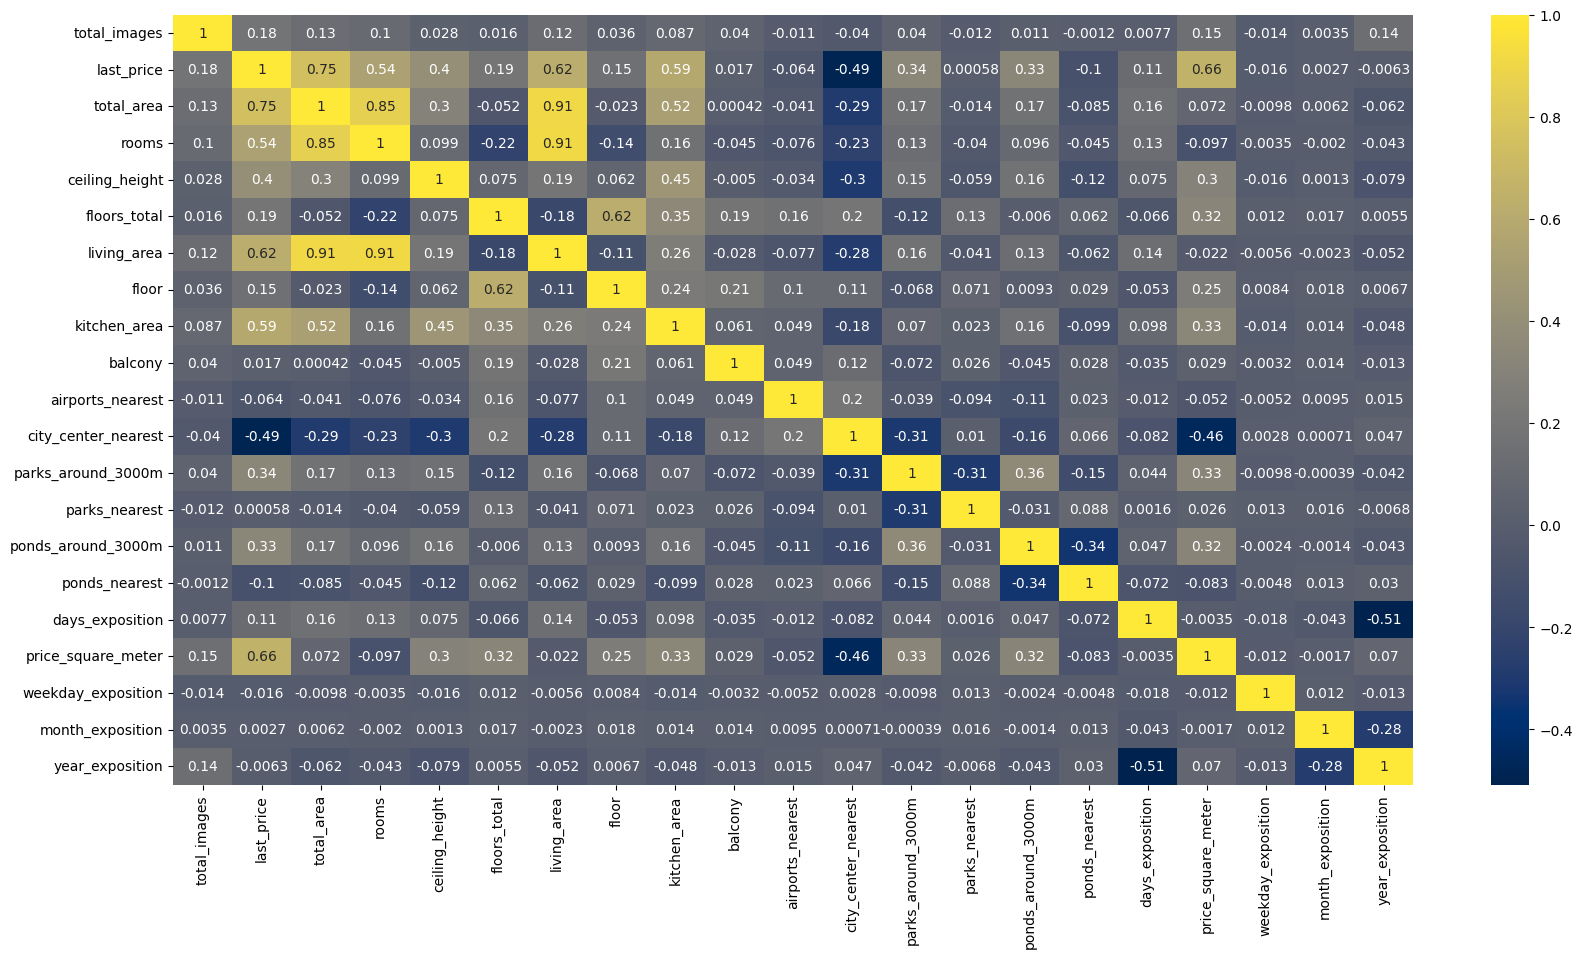

In [73]:
num_columns = data.select_dtypes(include='number').columns.tolist()
plt.figure(figsize=(20, 10))
sns.heatmap(data[num_columns].corr(method='spearman'), annot=True, cmap='cividis') 
plt.show();


На цену сильнее всего влияет общая площадь (0,75). Коэффициент положительный, т.е. при росте одной величины - растет другая. Чуть меньшее значение коэффициента корреляции между ценой и жилой площадью и ценой и площадью кухни, 0.62 и 0.59 соответственно. Это объяснимо, т.к. жилая площадь сильно коррелирует с общей (0.91). Дата размещения практически не влияет на цену.

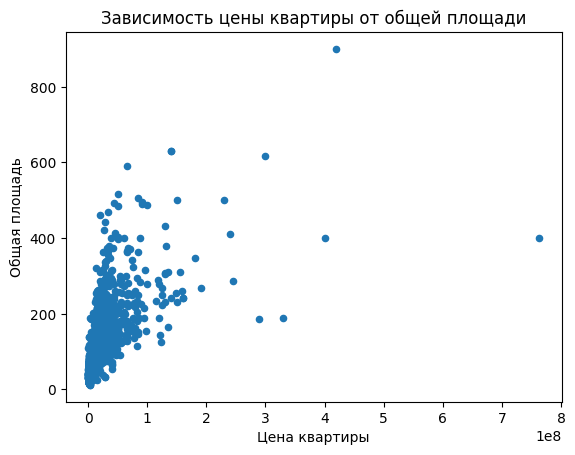

In [74]:
data.plot(x='last_price', y='total_area', kind='scatter')
plt.title('Зависимость цены квартиры от общей площади')
plt.xlabel('Цена квартиры')
plt.ylabel('Общая площадь')
plt.show();


На предыдущем этапе мы уже обратили внимание на наличие выбросов в данных. На графике они четко прослеживаются, попробуем построить график на сгруппированных данных, в качестве аггрегирующей функции укажем медиану. Это позволит снизить влияние выбросов. 

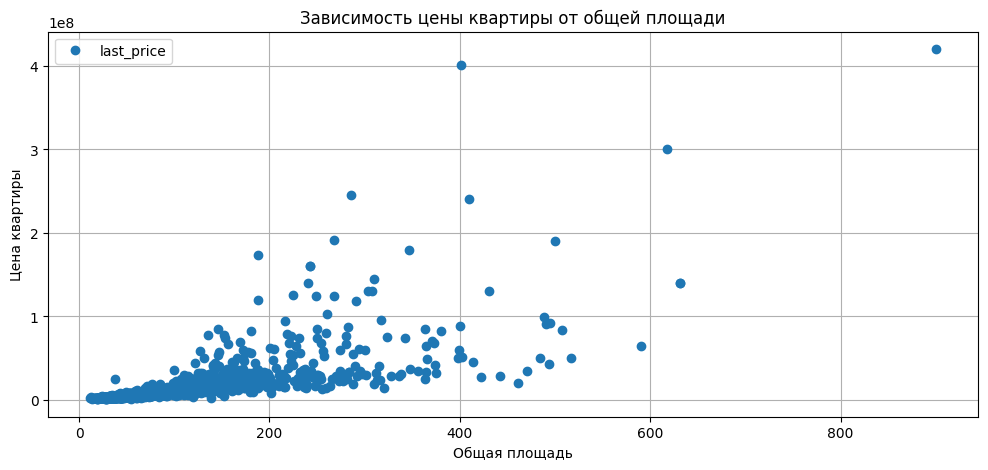

In [75]:
(data
     .pivot_table(index='total_area', values='last_price', aggfunc='median')
     .plot(grid=True, style='o', figsize=(12, 5))
)
plt.title('Зависимость цены квартиры от общей площади')
plt.xlabel('Общая площадь')
plt.ylabel('Цена квартиры')
plt.show();


Значительно улучшить ситуацию не удалось. Оценим количество выбросов для всех видов площади и стоимости квартир с помощью диаграммы размаха.

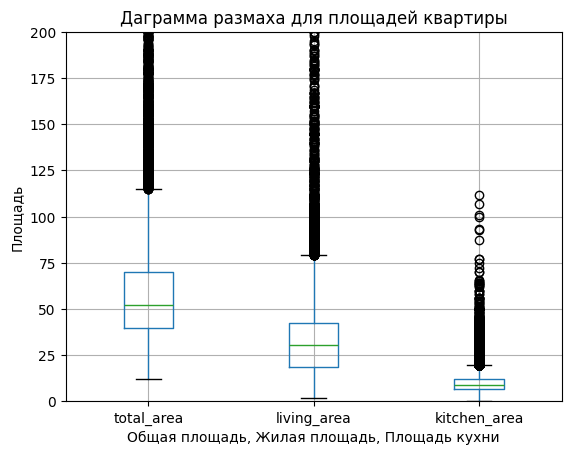

In [76]:
data.boxplot(['total_area', 'living_area', 'kitchen_area'])
plt.ylim(0, 200)
plt.title('Даграмма размаха для площадей квартиры')
plt.xlabel('Общая площадь, Жилая площадь, Площадь кухни')
plt.ylabel('Площадь')
plt.show();


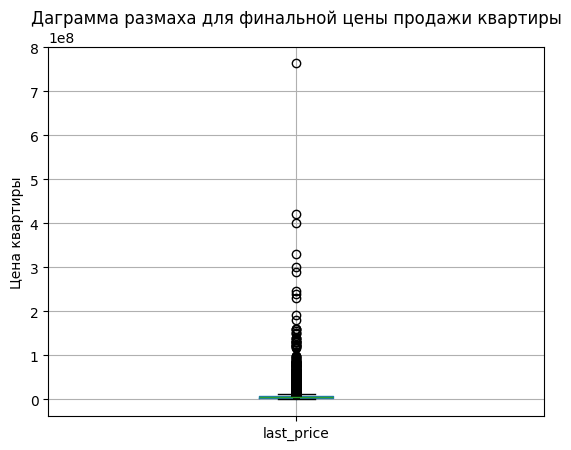

In [77]:
data.boxplot('last_price')
plt.title('Даграмма размаха для финальной цены продажи квартиры')
plt.ylabel('Цена квартиры')
plt.show();


Видим, что для всех изучаемых столбцов присутствует значительное количество выбросов. Удалим зачения, которые выходят за пределы "усов" диаграммы. Примем за нормальные значения, которые находятся на расстоянии 1,5 межквартильных размаха от первого и третьего квартиля. Рассчитаем эти значения и удалим все строки, значения в которых выходят за эти пределы. 

In [78]:
def remove_outliers_iqr(df, cols, k = 1.5):
    '''
    Функция удаляет выбросы по межквартильному размаху (IQR) для нескольких столбцов.
    Вычисляет границы на исходных данных и удаляет строки, где значение выходит за границы хотя бы в одном столбце.
    '''
    df = df.copy()
    mask = pd.Series(True, index=df.index)

    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        low = q1 - k * iqr
        high = q3 + k * iqr

        mask &= df[c].between(low, high)

    return df.loc[mask].copy()


In [79]:
data = remove_outliers_iqr(data, cols = ['total_area', 'living_area', 'kitchen_area', 'last_price'])


После удаления выбросов, построим графики повторно. Т.к. данных много и точки могут частично сливаться, применим группировку данных для улучшения визуализации.

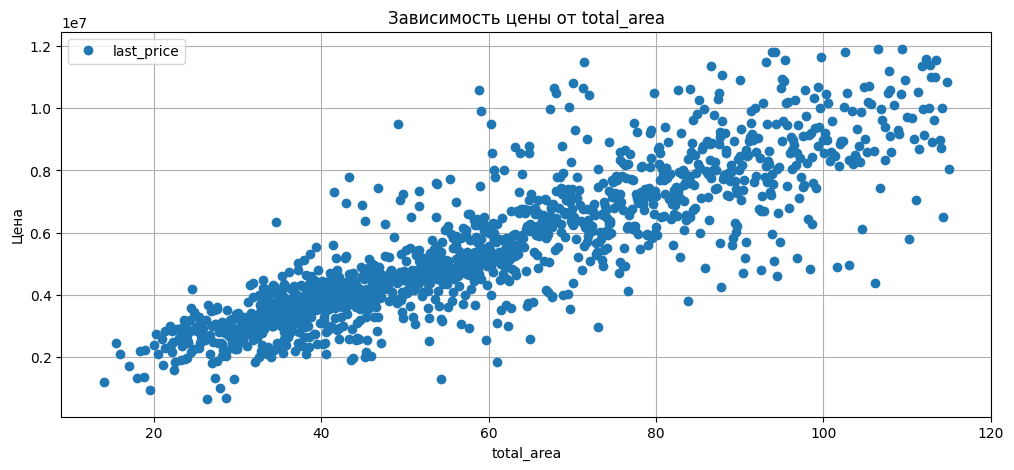

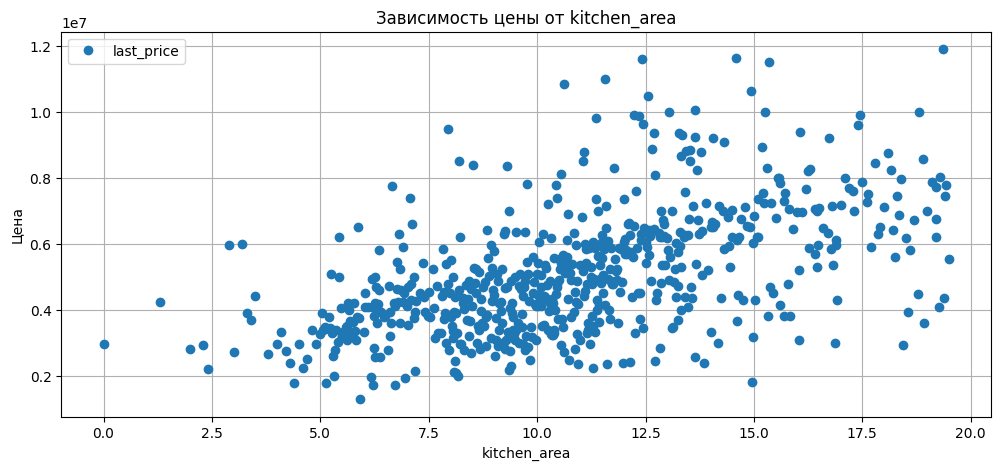

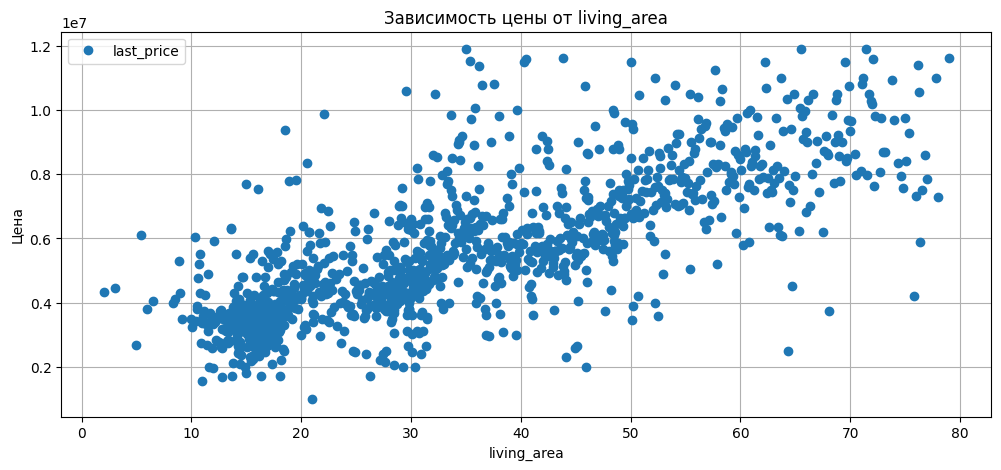

In [80]:
for index in ['total_area', 'kitchen_area', 'living_area']:
    (data
     .pivot_table(index=index, values='last_price')
     .plot(ylabel='Цена', grid=True, style='o', figsize=(12, 5), title=f'Зависимость цены от {index}')
)


<b>Вывод</b>

Цена имеет корреляцию с общей, жилой и кухонной площадью объекта недвижимости. Коэффициент коррелляции во всех трех случаях положителен, т.е. увеличение значения площади приводит к увеличению цены. 

Построим графики для оценки зависимости цены от количества комнат, этажа и даты размещения объявлений.

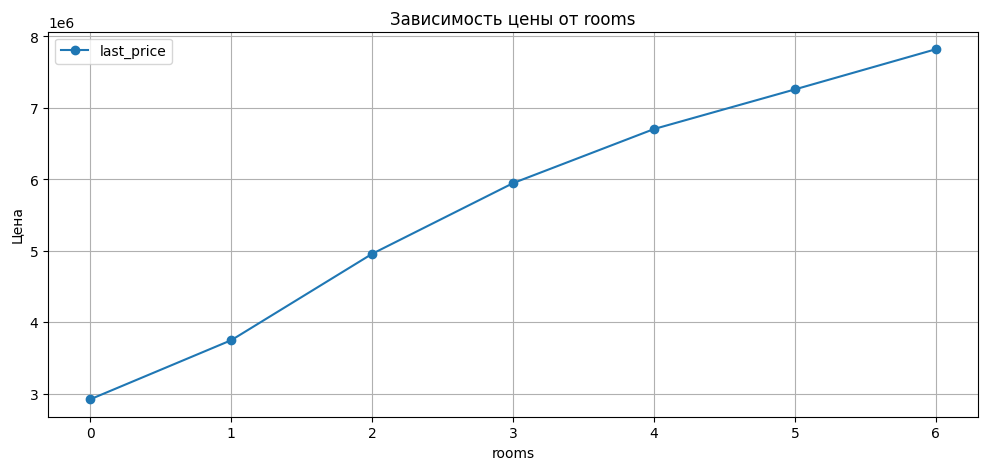

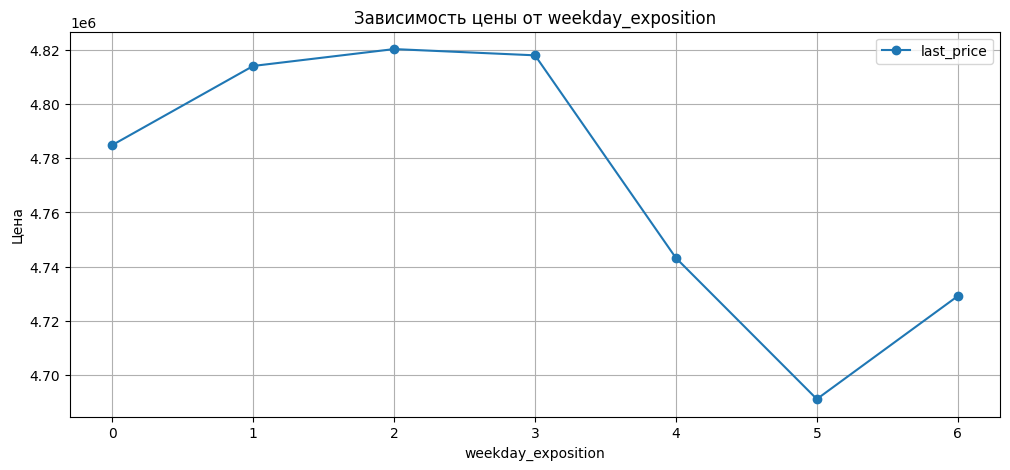

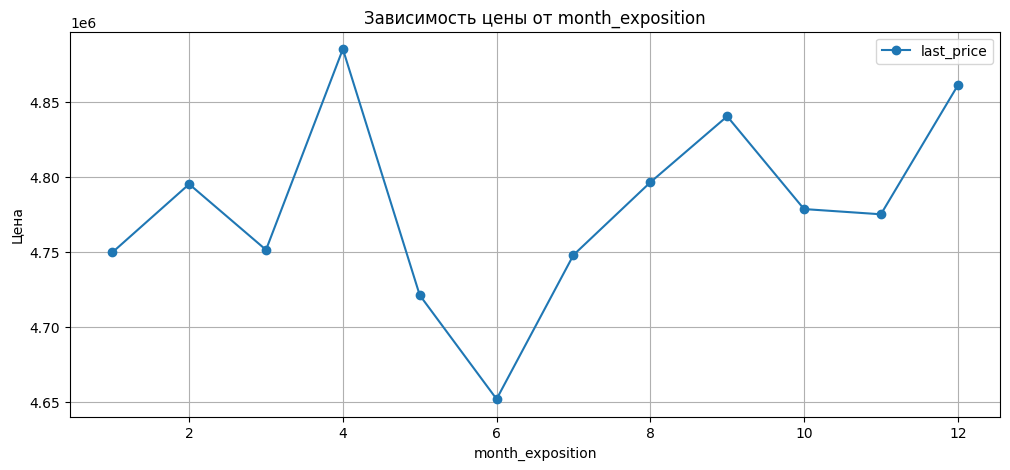

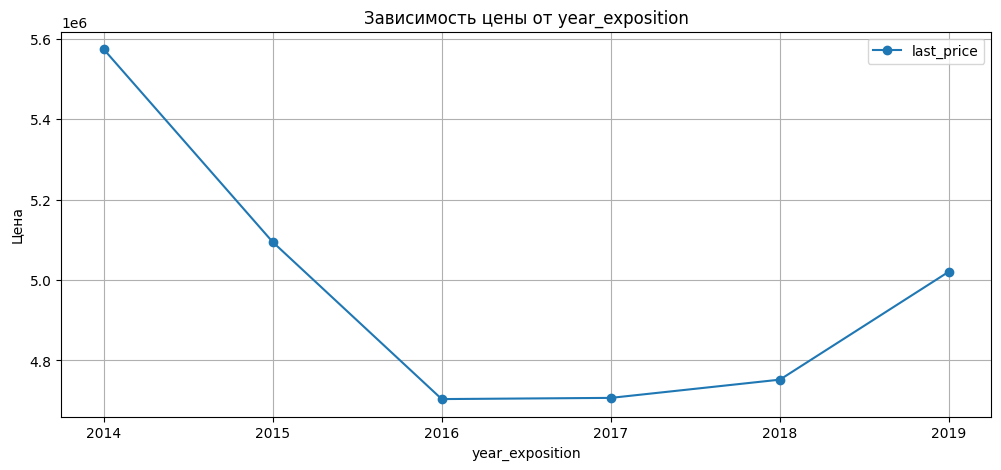

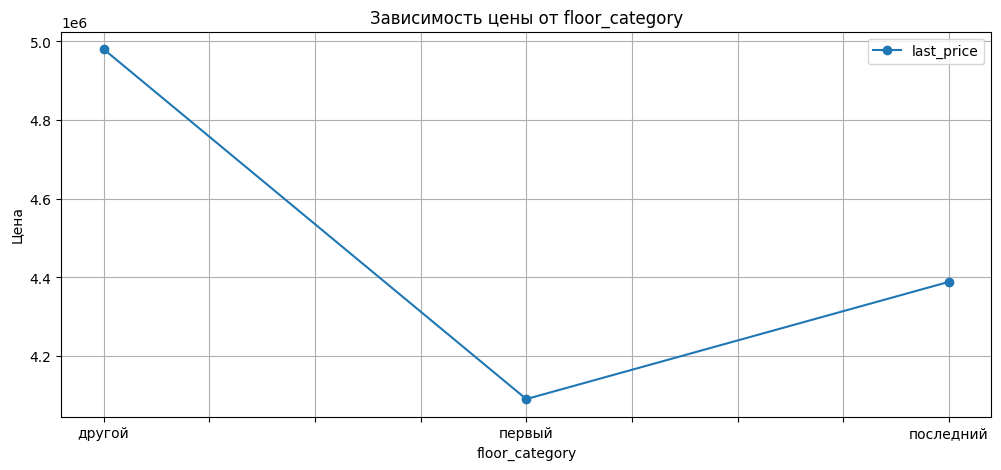

In [81]:
for index in ['rooms', 'weekday_exposition', 'month_exposition', 'year_exposition', 'floor_category']:
    (data
     .pivot_table(index=index, values='last_price')
     .plot(ylabel='Цена', grid=True, style='o-', figsize=(12, 5), title=f'Зависимость цены от {index}')
)


In [82]:
data['rooms'].value_counts()


rooms
1    7098
2    6773
3    4429
4     626
0     195
5      52
6       3
Name: count, dtype: int64

In [83]:
data['year_exposition'].value_counts()


year_exposition
2018    6816
2017    6743
2019    2384
2016    2264
2015     892
2014      77
Name: count, dtype: int64

<b>Вывод</b>

1. Стоимость квартиры линейно возрастает по мере увеличения комнат для 1-4-х комнатных квартир. Даных о стоимости 5 и 6-комнатных квартир не достаточно для выводов. 
2. Цена на квартиры чуть ниже в летний период. Вероятно, это может быть связано с тем, что спрос на недвижимость, как и на все продажи в целом, ниже (сезон отпусков). 
3. Цена на объекты размещенные в конце недели (выходные) незначительно ниже, сем на размещенные в будни.
4. Цены на квартиры растут, начиная с 2017 года. Данных за 2014 и 2015 год недостаточно для выводов.
5. Цены на квартиры, расположенные на первом и последнем этаже ниже, чем на остальные. При этом последний этаж чуть дороже, чем первый.

#### Цена квадратного метра в населенных пунктах

In [84]:
data['price_square_meter'].isna().sum()


np.int64(0)

In [85]:
(data
    .pivot_table(index='locality_name', values='price_square_meter', aggfunc=['mean', 'count'])
    .droplevel(1,axis=1) 
    .sort_values(by='count', ascending=False)  
    .reset_index()
    .rename(columns=
                   {'locality_name': 'Город',
                   'mean': 'Средняя цена за кв.м',
                   'count': 'Количество объявлений'}) 
    .loc[0:9]
    .sort_values(by='Средняя цена за кв.м', ascending=False)
)


,Город,Средняя цена за кв.м,Количество объявлений
0,санкт-петербург,105220.984745,12237
6,пушкин,100132.681007,298
3,кудрово,95754.252571,389
7,парголово,90359.600759,290
1,мурино,86405.643287,499
2,шушары,78807.152987,395
5,колпино,74981.475696,316
8,гатчина,68400.666028,287
4,всеволожск,67146.753314,353
9,выборг,58242.910909,187


<b>Вывод</b>

Санк-Петербург - населенный пункт с самой высокой стоимостью квадратного метра, Всеволжск - с самой низкой стоимостью из ТОП-10 по количеству объявлений. 

#### Средняя стоиомсть недвижимости в зависимости от удаленности от центра

,Расстояние от центра км,Средняя цена
0,0.0,8.060000e+06
1,1.0,8.213709e+06
2,2.0,7.786500e+06
3,3.0,7.005629e+06
4,4.0,7.476769e+06
5,5.0,7.532035e+06
6,6.0,6.962809e+06
7,7.0,6.559468e+06
8,8.0,6.522456e+06
9,9.0,5.526365e+06


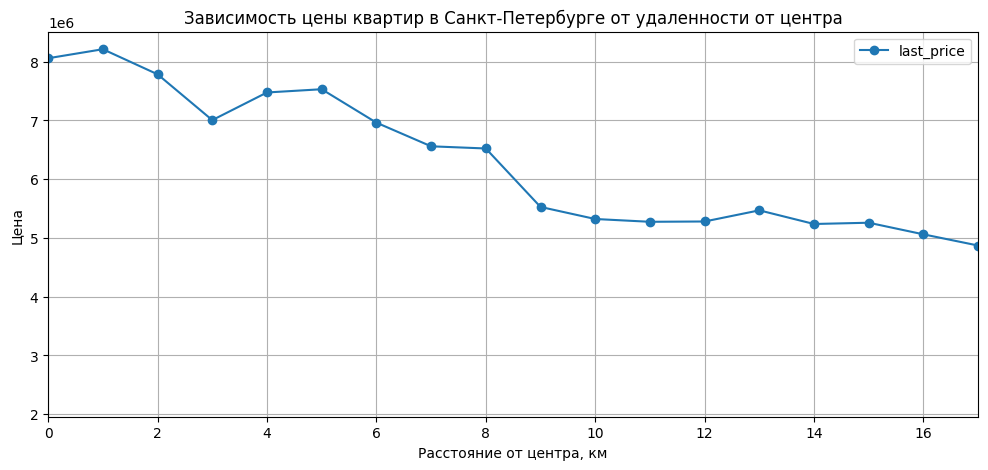

In [86]:
(data
    .query('locality_name == "санкт-петербург"')
    .pivot_table(index='city_center_nearest', values='last_price')
    .plot(xlabel='Расстояние от центра, км', ylabel='Цена',
          xlim=(0,17), grid=True, style='o-', figsize=(12, 5), 
          title='Зависимость цены квартир в Санкт-Петербурге от удаленности от центра')
)
(data
    .query('locality_name == "санкт-петербург"')
    .pivot_table(index='city_center_nearest', values='last_price')
    .head(10)
    .reset_index()
    .rename(columns=
                   {'city_center_nearest': 'Расстояние от центра км',
                   'last_price': 'Средняя цена'}) 
)


<b>Вывод</b>

Самые дорогие квартиры расположены в центре. До 9 км стоимость квартир убывает по мере удаления от центра. Начиная с 10 км  до 16км стоимость остается примерно на одном уровне. 

<b>Вывод по разделу "Исследовательский анализ данных"</b>

1. Изучены различные параметры объектов. Наиболее распространены объявления 1-2 комнатных квартир, с общей площадью до 45 кв.м. Расстояние от центра составляет 8-12 км. Большую долю занимают объявления на первом и последнем этаже, однако, объекты на других этажах все же преобладают. У большинства объектов на расстоянии до 1,2 км есть парк. 

2. Изучена скорость продажи квартир. Медианное значение для скорости продажи - 3 месяца. Быстрыми можно считать продажи быстрее 45 дней. Медленными - больше 232 дня. 

3. Изучены факторы влияющие на стоимость квартиры. В ходе анализа удалены выбросы для полей со значениями цены и площади объекта, выходящие за пределы "усов" диаграммы размаха. Стоимость квартиры линейно возрастает по мере увеличения комнат для 1-4-х комнатных квартир. Цены на квартиры, расположенные на первом и последнем этаже ниже, чем на остальные. При этом последний этаж чуть дороже, чем первый.

4. Среди ТОП-10 по количеству объявлений в Санкт-Петербурге и Ленинградской области самая высокая цена у Санкт-Петербурга, самая низкая - у Всеволжска. 

5. Самая дорогая недвижимость в Санкт-Петербурге расположена в центре, по мере удаления от центра стоимость линейно снижается до 10 км. По мере дальнейшего удаления стоимость значительно не изменяется.

### Общий вывод

В ходе первичной предобработки данных было выполнено следующее:
    
- заполнены пропуски в колонках с числом парков и водоемов на расстоянии до 3км, наличием балкона, "флагом" апартаментов, высотой потолков и общим количеством этажей в здании
- частично, там где это было возможно, заполнены пропуски в колонках с названием населенного пункта, площадью кухни и расстоянием до центра города и аэропорта
- тип данных для целочисленных значений изменен на int (кол-во балконов, кол-во этажей, кол-во парков и водоемов)
- тип данных для логических значений изменен на bool (апартаменты)
- тип данных для даты размещения объявления изменен на datetime
- расстояние до центра переведено в км

В ходе подготовки данных к анализу:
- добавлены столбцы с информацией о цене квадратного метра, годе, месяце и дне недели публикации объявления
- категоризованы данные об этаже (первый, последний, другое)

В ходе анализа данных:
1. Изучены различные параметры объектов.

Исходя из полученных данных можно сделать вывод, что **среднестатистичекое предложение на рынке** - это 1 или 2-х комнатная квартира общей площадью около 45м в 5-ти этажке. В спальном районе, на расстоянии 8-12 км от центра. Поблизости есть парк. Продажа в среднем займет около 3 месяцев.

2. Изучены факторы влияющие на стоимость квартиры. В ходе анализа удалены выбросы для полей со значениями цены и площади объекта, выходящие за пределы "усов" диаграммы размаха.

Исходя из полученных данных можно сделать вывод, что наибольшее влияние на **рыночную стоимость объекта** оказывает площадь: чем выше площадь, тем выше цена. Также цена увеличивается с ростом количества комнат. Объекты расположенные на первом и последнем этажах имеют более низкую цену. В летний период цены объектов незначительно снижаются. Стоимость недвижимости непрерывно увеличивается начиная с 2017 года.

3. Среди ТОП-10 по количеству объявлений в Санкт-Петербурге и Ленинградской области самая высокая цена у Санкт-Петербурга, самая низкая - у Всеволжска. В среднем квадратный метр в Санкт-Петербурге дороже, чем во Всеволжске на 56%. 

4. Самая дорогая недвижимость в Санкт-Петербурге расположена в центре, по мере удаления от центра стоимость линейно снижается до 10 км. По мере дальнейшего удаления стоимость значительно не изменяется.


В качестве рекомендации для улучшения качества данных можно изменить правила заполнения полей в объявлениях, сделав
заполнение пунктов на сайте обязательным. Также можно перепроверить корректность опеределения расстояния картографическим сервисом, т.к. для ряда населенных пунктов расстояние определялось не всегда. Например, для Мурино расстояние было определено только для нескольких объявлений из 500.

Также для ускорения обработки данных можно изменить формат в ряде полей на соотвествующий сразу при выгрузке. Добавить автопроверку на формат вводимых пользователем данных (например, для высоты потолка).

Можно также попробовать оценить влияние на рыночную стоимость жилья других факторов:
- рассмотреть две категории жилья по-отдельности: вторичное жилье/новостройка
- наличие/отсутствие ремонта
- близость к другим объектам инфраструктуры: медицинским центрам, торговым центрам, транспортным развязкам
- близость к станции метро (для Санкт-Петербурга)